# Movie Master EDA
- 데이터 출처: `integrated_analysis.db` → `movie_master` 테이블
- 분석 항목: 장르, 국가, 상영시간, 출시월, repurchase 연결

In [11]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import re
from collections import Counter

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# DB 연결
DB_PATH = r'../integrated_analysis.db'
conn = sqlite3.connect(DB_PATH)

mm = pd.read_sql('SELECT * FROM movie_master', conn)
membership = pd.read_sql('SELECT * FROM membership', conn)
user_mapping = pd.read_sql('SELECT uid, USER_ID FROM user_mapping', conn)
view_history = pd.read_sql('SELECT * FROM view_history', conn)
conn.close()

print(f'movie_master: {mm.shape}')
print(mm.dtypes)
mm.head(3)

movie_master: (14018, 7)
MOVIE_ID          int64
TITLE            object
RELEASE_MONTH     int64
GENRE            object
COUNTRY          object
DURATION         object
OTHER_INFO       object
dtype: object


,MOVIE_ID,TITLE,RELEASE_MONTH,GENRE,COUNTRY,DURATION,OTHER_INFO
0,0,걸어서하늘까지(1992),202103,"로맨스, 드라마",대한민국,1시간 56분,"감독: Jang Hyeon-su / 출연진: Bae Jong-ok, Ji-sook,..."
1,1,너와극장에서,201807,드라마,대한민국,1시간 19분,"감독: Jeong Ga-young, Yoo Ji-young / 출연진: Kim Ya..."
2,2,가려진시간[가치봄],202010,"판타지, 드라마",대한민국,2시간 9분,"감독: Um Tae-hwa / 출연진: Gang Dong-won, Sung-min,..."


## 1. 기본 현황 및 결측치

In [12]:
print('=== 결측치 현황 ===')
missing = mm.isnull().sum()
missing_pct = (mm.isnull().sum() / len(mm) * 100).round(2)
print(pd.DataFrame({'결측수': missing, '결측률(%)': missing_pct}))

print('\n=== 빈 문자열 현황 ===')
for col in ['GENRE', 'COUNTRY', 'DURATION', 'OTHER_INFO']:
    empty = (mm[col].fillna('') == '').sum()
    print(f'{col}: {empty}개 ({empty/len(mm)*100:.1f}%)')

=== 결측치 현황 ===
               결측수  결측률(%)
MOVIE_ID         0    0.00
TITLE            0    0.00
RELEASE_MONTH    0    0.00
GENRE          149    1.06
COUNTRY          9    0.06
DURATION        13    0.09
OTHER_INFO      33    0.24

=== 빈 문자열 현황 ===
GENRE: 149개 (1.1%)
COUNTRY: 2937개 (21.0%)
DURATION: 13개 (0.1%)
OTHER_INFO: 33개 (0.2%)


## 2. 장르 분포
GENRE 컬럼은 `'드라마, 액션'` 처럼 쉼표로 묶인 멀티값 → 분리해서 분석

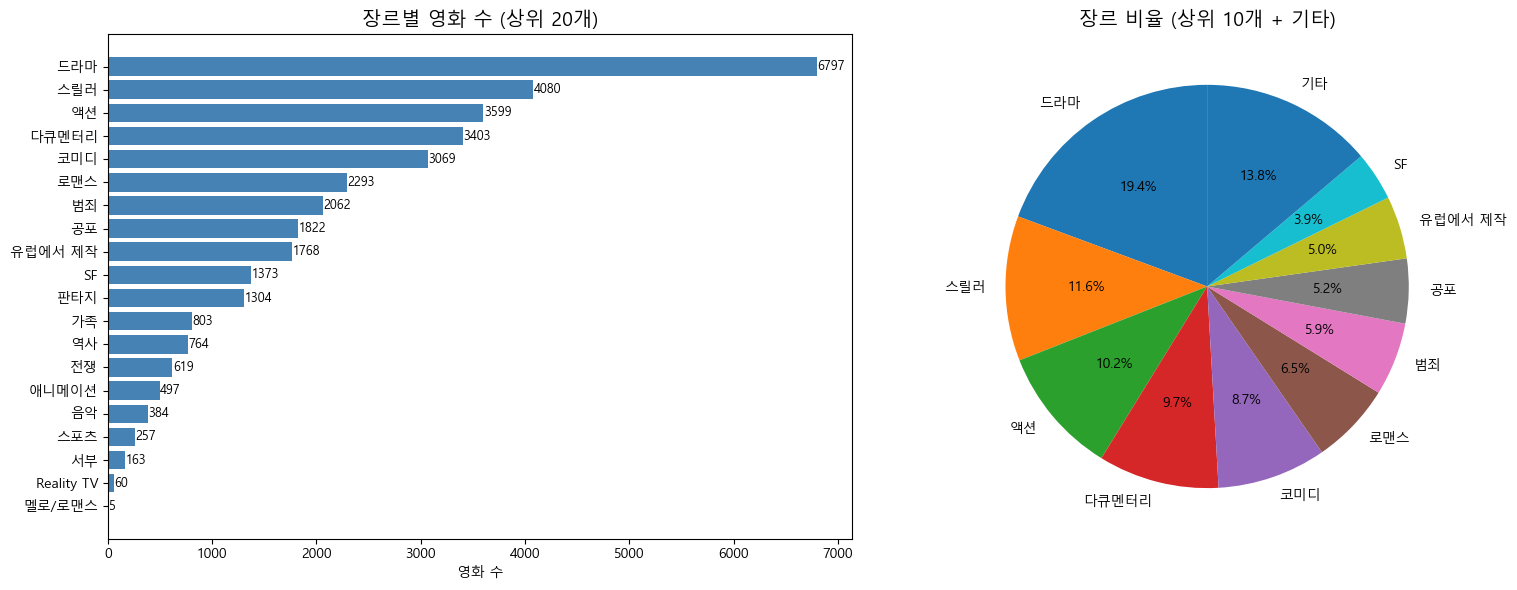


전체 고유 장르 수: 22개
        장르  영화수
       드라마 6797
       스릴러 4080
        액션 3599
     다큐멘터리 3403
       코미디 3069
       로맨스 2293
        범죄 2062
        공포 1822
   유럽에서 제작 1768
        SF 1373
       판타지 1304
        가족  803
        역사  764
        전쟁  619
     애니메이션  497
        음악  384
       스포츠  257
        서부  163
Reality TV   60
    멜로/로맨스    5


In [13]:
# 장르 분리
all_genres = []
for g in mm['GENRE'].dropna():
    parts = [x.strip() for x in str(g).split(',') if x.strip()]
    all_genres.extend(parts)

genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.most_common(20), columns=['장르', '영화수'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 상위 20개 장르
axes[0].barh(genre_df['장르'][::-1], genre_df['영화수'][::-1], color='steelblue')
axes[0].set_title('장르별 영화 수 (상위 20개)', fontsize=14)
axes[0].set_xlabel('영화 수')
for i, (v, l) in enumerate(zip(genre_df['영화수'][::-1], genre_df['장르'][::-1])):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# 상위 10개 파이차트
top10 = genre_df.head(10)
others = pd.DataFrame([['기타', genre_df['영화수'][10:].sum()]], columns=['장르', '영화수'])
pie_df = pd.concat([top10, others])
axes[1].pie(pie_df['영화수'], labels=pie_df['장르'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('장르 비율 (상위 10개 + 기타)', fontsize=14)

plt.tight_layout()
plt.show()

print(f'\n전체 고유 장르 수: {len(genre_counts)}개')
print(genre_df.to_string(index=False))

## 3. 국가 분포

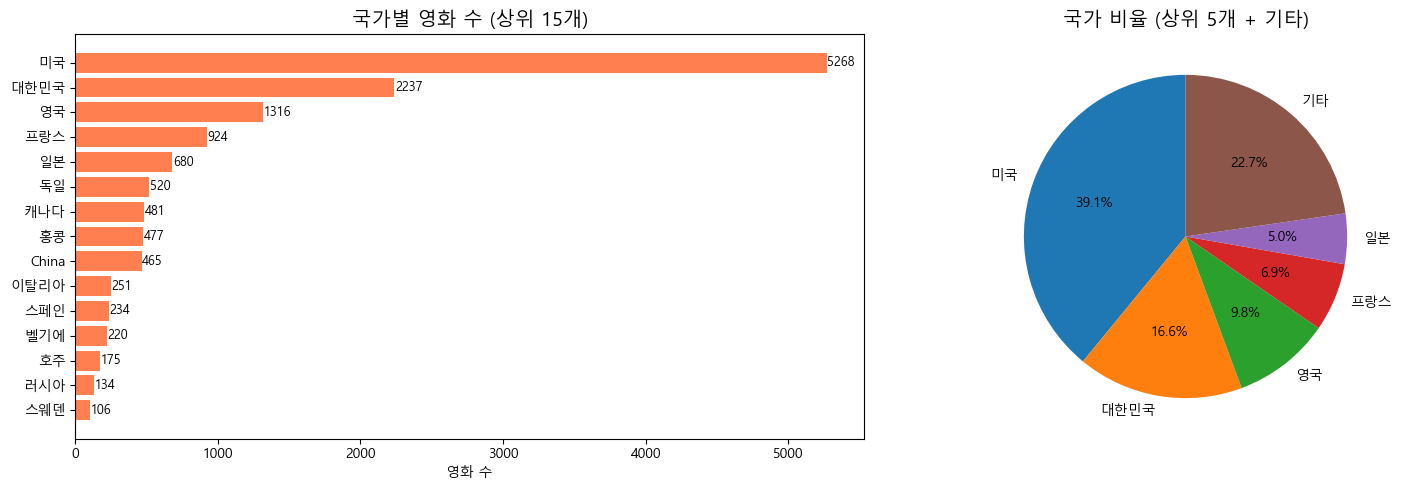

국가 결측: 2946개
   국가  영화수
   미국 5268
 대한민국 2237
   영국 1316
  프랑스  924
   일본  680
   독일  520
  캐나다  481
   홍콩  477
China  465
 이탈리아  251
  스페인  234
  벨기에  220
   호주  175
  러시아  134
  스웨덴  106


In [14]:
# 국가도 쉼표 멀티값일 수 있음
all_countries = []
for c in mm['COUNTRY'].dropna():
    parts = [x.strip() for x in str(c).split(',') if x.strip()]
    all_countries.extend(parts)

country_counts = Counter(all_countries)
country_df = pd.DataFrame(country_counts.most_common(15), columns=['국가', '영화수'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(country_df['국가'][::-1], country_df['영화수'][::-1], color='coral')
axes[0].set_title('국가별 영화 수 (상위 15개)', fontsize=14)
axes[0].set_xlabel('영화 수')
for i, v in enumerate(country_df['영화수'][::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

top5 = country_df.head(5)
others_c = pd.DataFrame([['기타', country_df['영화수'][5:].sum()]], columns=['국가', '영화수'])
pie_c = pd.concat([top5, others_c])
axes[1].pie(pie_c['영화수'], labels=pie_c['국가'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('국가 비율 (상위 5개 + 기타)', fontsize=14)

plt.tight_layout()
plt.show()

print(f'국가 결측: {mm["COUNTRY"].isna().sum() + (mm["COUNTRY"].fillna("") == "").sum()}개')
print(country_df.to_string(index=False))

## 4. 상영시간 분포
`'1시간 56분'` 형태 → 분(min) 단위로 변환

상영시간(분) 기초통계:
count    14005.000000
mean        98.449839
std         22.423891
min          5.000000
25%         85.000000
50%         96.000000
75%        111.000000
max        270.000000
Name: duration_min, dtype: float64


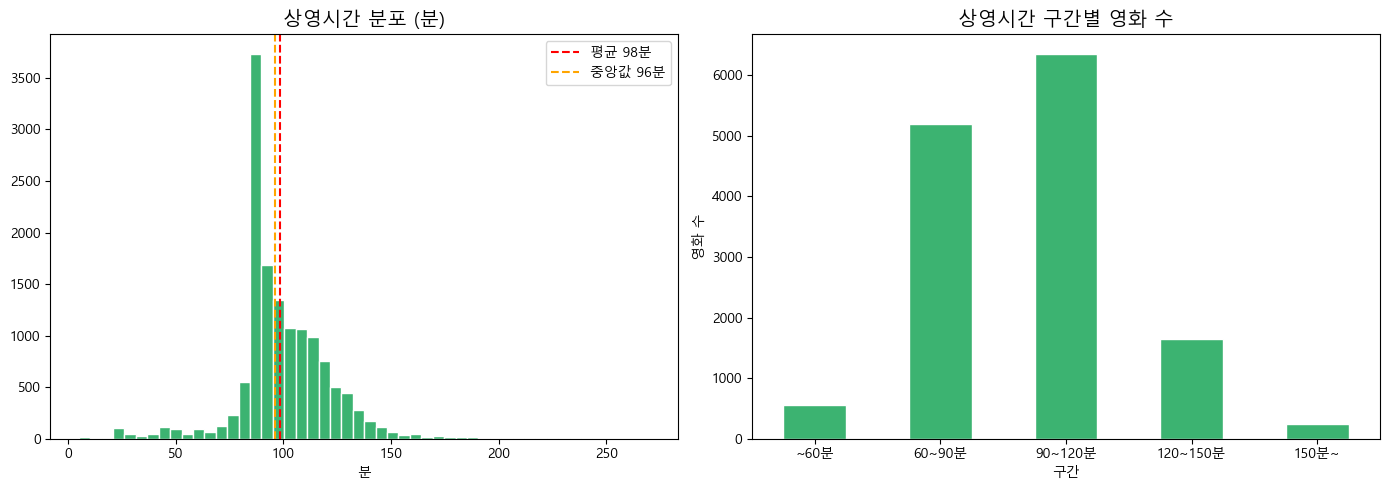

In [15]:
def parse_duration(s):
    if pd.isna(s) or s == '':
        return np.nan
    h = re.search(r'(\d+)시간', str(s))
    m = re.search(r'(\d+)분', str(s))
    hours = int(h.group(1)) if h else 0
    mins  = int(m.group(1)) if m else 0
    total = hours * 60 + mins
    return total if total > 0 else np.nan

mm['duration_min'] = mm['DURATION'].apply(parse_duration)

print('상영시간(분) 기초통계:')
print(mm['duration_min'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid = mm['duration_min'].dropna()
axes[0].hist(valid, bins=50, color='mediumseagreen', edgecolor='white')
axes[0].axvline(valid.mean(), color='red', linestyle='--', label=f'평균 {valid.mean():.0f}분')
axes[0].axvline(valid.median(), color='orange', linestyle='--', label=f'중앙값 {valid.median():.0f}분')
axes[0].set_title('상영시간 분포 (분)', fontsize=14)
axes[0].set_xlabel('분')
axes[0].legend()

# 90분 기준 분류
bins_label = ['~60분', '60~90분', '90~120분', '120~150분', '150분~']
bins_cut = pd.cut(valid, bins=[0, 60, 90, 120, 150, 9999], labels=bins_label)
bins_cut.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('상영시간 구간별 영화 수', fontsize=14)
axes[1].set_xlabel('구간')
axes[1].set_ylabel('영화 수')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5. RELEASE_MONTH 분포
형식: `202103` (YYYYMM)

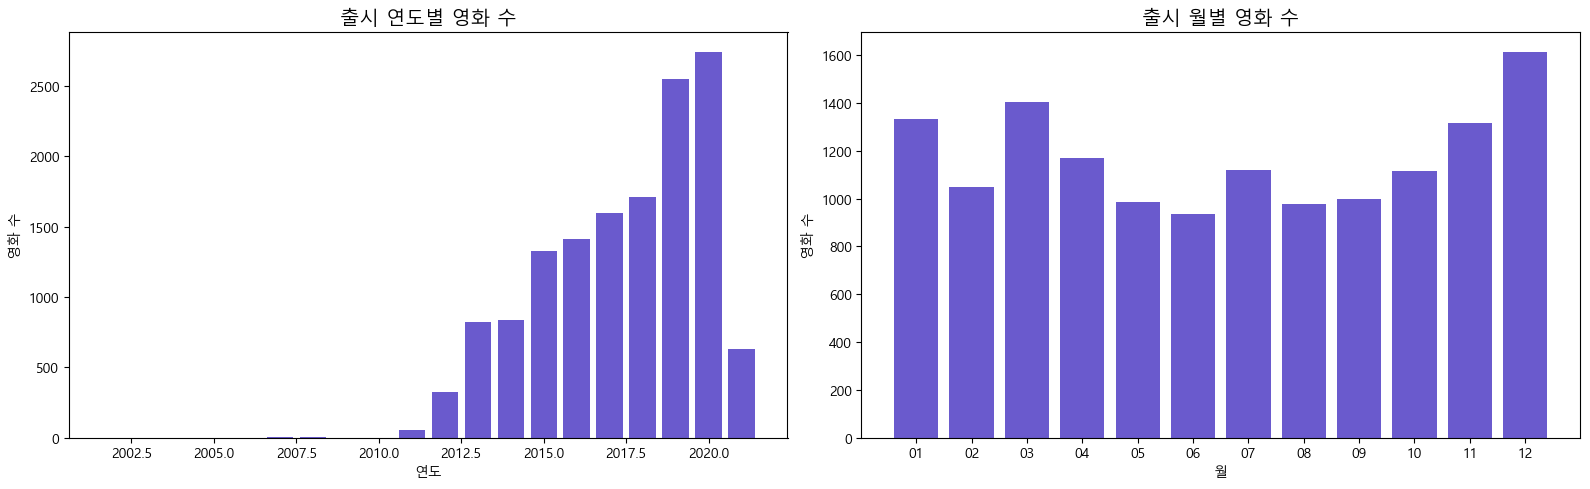

연도 상위 10개:
release_year
2020    2744
2019    2551
2018    1713
2017    1596
2016    1415
2015    1324
2014     836
2013     826
2021     630
2012     322
Name: count, dtype: int64


In [16]:
mm['release_year'] = mm['RELEASE_MONTH'].astype(str).str[:4].astype(int, errors='ignore')
mm['release_month_only'] = mm['RELEASE_MONTH'].astype(str).str[4:6]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 연도별
year_counts = mm['release_year'].value_counts().sort_index()
# 합리적인 범위만
year_counts = year_counts[(year_counts.index >= 1950) & (year_counts.index <= 2025)]
axes[0].bar(year_counts.index, year_counts.values, color='slateblue', width=0.8)
axes[0].set_title('출시 연도별 영화 수', fontsize=14)
axes[0].set_xlabel('연도')
axes[0].set_ylabel('영화 수')

# 월별
month_counts = mm['release_month_only'].value_counts().sort_index()
month_counts = month_counts[month_counts.index.str.match(r'^\d{2}$')]
axes[1].bar(month_counts.index, month_counts.values, color='slateblue')
axes[1].set_title('출시 월별 영화 수', fontsize=14)
axes[1].set_xlabel('월')
axes[1].set_ylabel('영화 수')

plt.tight_layout()
plt.show()

print('연도 상위 10개:')
print(year_counts.sort_values(ascending=False).head(10))

## 6. 시청 이력 연결: 많이 본 영화 TOP 20

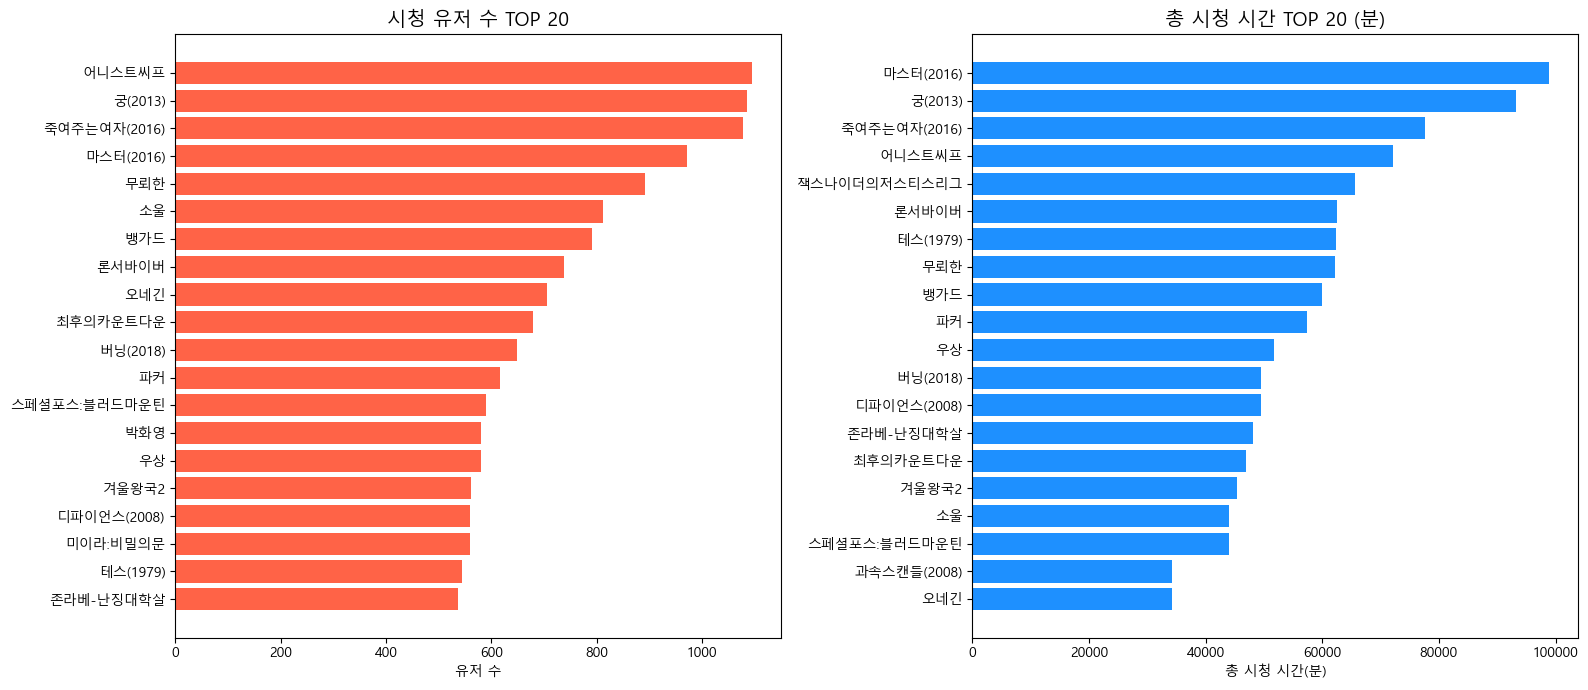

시청 유저 수 TOP 10:
       TITLE                        GENRE  view_count  total_duration
      어니스트씨프             액션, 범죄, 드라마, 스릴러        1096           72111
     궁(2013)                코미디, 드라마, 로맨스        1086           93152
죽여주는여자(2016)                          드라마        1079           77687
   마스터(2016)                 드라마, 유럽에서 제작         972           98950
         무뢰한            드라마, 범죄, 로맨스, 스릴러         892           62178
          소울 판타지, 애니메이션, 가족, 드라마, 음악, 코미디         813           43994
         뱅가드             액션, 코미디, 범죄, 스릴러         792           60028
       론서바이버                           액션         738           62510
         오네긴                     로맨스, 드라마         705           34228
    최후의카운트다운       드라마, 스릴러, 코미디, 액션, 로맨스         679           46847


In [17]:
# view_history + movie_master 조인
vh_agg = view_history.groupby('MOVIE_ID').agg(
    view_count=('USER_ID', 'nunique'),
    total_duration=('DURATION', 'sum')
).reset_index()

vh_mm = vh_agg.merge(mm[['MOVIE_ID', 'TITLE', 'GENRE', 'COUNTRY', 'duration_min']], on='MOVIE_ID', how='left')
vh_mm = vh_mm.sort_values('view_count', ascending=False)

top20 = vh_mm.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 시청 유저 수 기준
axes[0].barh(top20['TITLE'][::-1], top20['view_count'][::-1], color='tomato')
axes[0].set_title('시청 유저 수 TOP 20', fontsize=14)
axes[0].set_xlabel('유저 수')

# 총 시청 시간 기준
top20_dur = vh_mm.sort_values('total_duration', ascending=False).head(20)
axes[1].barh(top20_dur['TITLE'][::-1], top20_dur['total_duration'][::-1], color='dodgerblue')
axes[1].set_title('총 시청 시간 TOP 20 (분)', fontsize=14)
axes[1].set_xlabel('총 시청 시간(분)')

plt.tight_layout()
plt.show()

print('시청 유저 수 TOP 10:')
print(top20[['TITLE', 'GENRE', 'view_count', 'total_duration']].head(10).to_string(index=False))

## 7. 장르별 시청 패턴

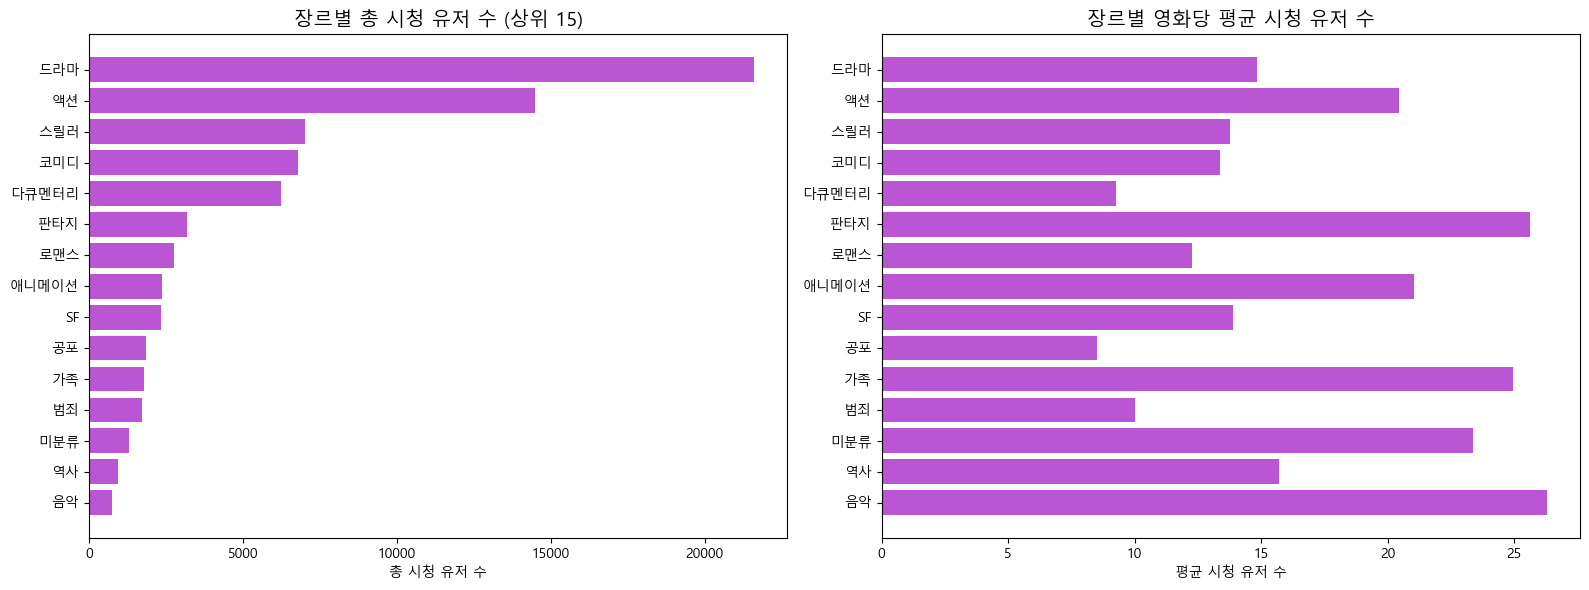

main_genre  영화수  총시청유저    평균시청유저   총시청시간
       드라마 1458  21613 14.823731 1303165
        액션  708  14487 20.461864 1043314
       스릴러  510   7012 13.749020  433206
       코미디  509   6797 13.353635  455138
     다큐멘터리  672   6226  9.264881  279888
       판타지  124   3176 25.612903  206855
       로맨스  225   2756 12.248889  141234
     애니메이션  113   2377 21.035398  144484
        SF  169   2345 13.875740  153991
        공포  217   1850  8.525346   91346
        가족   72   1797 24.958333  130057
        범죄  172   1721 10.005814  113501
       미분류   56   1309 23.375000   85099
        역사   60    942 15.700000   60776
        음악   28    736 26.285714   38943


In [18]:
# 영화별 주요 장르 (첫 번째 장르만)
mm['main_genre'] = mm['GENRE'].fillna('').apply(lambda x: x.split(',')[0].strip() if x else '미분류')

vh_genre = vh_mm.copy()
vh_genre['main_genre'] = vh_genre['GENRE'].fillna('').apply(lambda x: x.split(',')[0].strip() if x else '미분류')

genre_stat = vh_genre.groupby('main_genre').agg(
    영화수=('MOVIE_ID', 'count'),
    총시청유저=('view_count', 'sum'),
    평균시청유저=('view_count', 'mean'),
    총시청시간=('total_duration', 'sum')
).reset_index().sort_values('총시청유저', ascending=False)

top_genre_stat = genre_stat.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_genre_stat['main_genre'][::-1], top_genre_stat['총시청유저'][::-1], color='mediumorchid')
axes[0].set_title('장르별 총 시청 유저 수 (상위 15)', fontsize=14)
axes[0].set_xlabel('총 시청 유저 수')

axes[1].barh(top_genre_stat['main_genre'][::-1], top_genre_stat['평균시청유저'][::-1], color='mediumorchid')
axes[1].set_title('장르별 영화당 평균 시청 유저 수', fontsize=14)
axes[1].set_xlabel('평균 시청 유저 수')

plt.tight_layout()
plt.show()

print(top_genre_stat[['main_genre', '영화수', '총시청유저', '평균시청유저', '총시청시간']].to_string(index=False))

## 8. 장르 × repurchase 연결
유저가 주로 본 장르가 재결제율에 영향을 주는지 확인

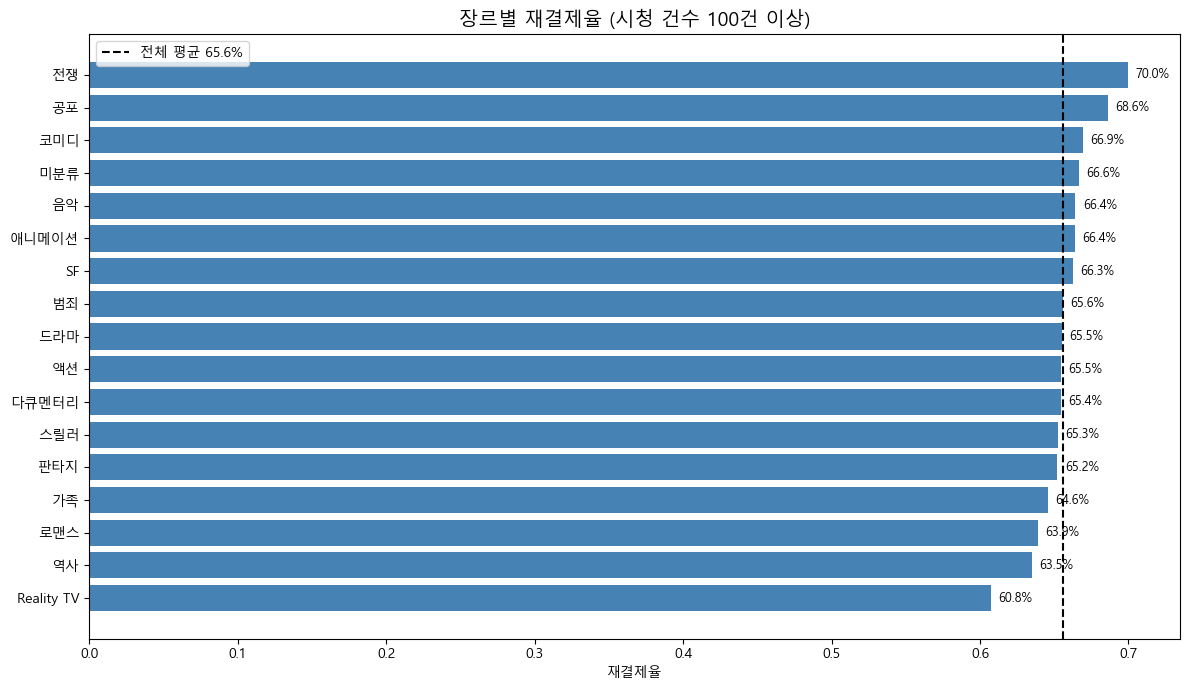

main_genre  총시청건수     재결제율
        전쟁    678 0.699704
        공포   2469 0.685877
       코미디   9412 0.669046
       미분류   1811 0.666482
        음악    969 0.664256
     애니메이션   3819 0.664036
        SF   3639 0.662541
        범죄   2244 0.656082
       드라마  28491 0.654977
        액션  21550 0.654505
     다큐멘터리   8049 0.654471
       스릴러   9379 0.652638
       판타지   5285 0.652174
        가족   3239 0.645730
       로맨스   3546 0.639196
        역사   1274 0.635071
Reality TV    237 0.607595


In [19]:
# membership repurchase 인코딩
membership['repurchase_bin'] = membership['repurchase'].apply(lambda x: 1 if x == 'O' else 0)

# user_mapping으로 USER_ID → user_no 연결
uid_map = user_mapping.rename(columns={'uid': 'user_no'})

# view_history에 user_no 붙이기
vh_user = view_history.merge(uid_map, on='USER_ID', how='left')
vh_user = vh_user.merge(mm[['MOVIE_ID', 'main_genre']], on='MOVIE_ID', how='left')
vh_user = vh_user.merge(membership[['user_no', 'repurchase_bin']], on='user_no', how='left')

# 장르별 재결제율
genre_repurchase = vh_user.groupby('main_genre').agg(
    총시청건수=('MOVIE_ID', 'count'),
    재결제율=('repurchase_bin', 'mean')
).reset_index()
genre_repurchase = genre_repurchase[genre_repurchase['총시청건수'] >= 100].sort_values('재결제율', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['tomato' if r < 0.6 else 'steelblue' for r in genre_repurchase['재결제율']]
bars = ax.barh(genre_repurchase['main_genre'][::-1], genre_repurchase['재결제율'][::-1], color=colors[::-1])
ax.axvline(0.656, color='black', linestyle='--', label='전체 평균 65.6%')
ax.set_title('장르별 재결제율 (시청 건수 100건 이상)', fontsize=14)
ax.set_xlabel('재결제율')
ax.legend()
for bar, val in zip(bars, genre_repurchase['재결제율'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(genre_repurchase[['main_genre', '총시청건수', '재결제율']].to_string(index=False))

## 9. 유저별 시청 패턴 — view_history 기반
누가 얼마나 많이, 어떤 영화를 봤는지

유저별 시청 통계 기초 분석:
         총시청건수    고유영화수    총시청시간     시청일수
count  14892.0  14892.0  14892.0  14892.0
mean       7.1      5.1    317.1      3.9
std        6.0      4.3    327.5      2.6
min        1.0      1.0      1.0      1.0
25%        3.0      2.0     98.0      2.0
50%        6.0      4.0    225.0      3.0
75%       10.0      7.0    436.0      5.0
max       75.0     67.0   4419.0     21.0


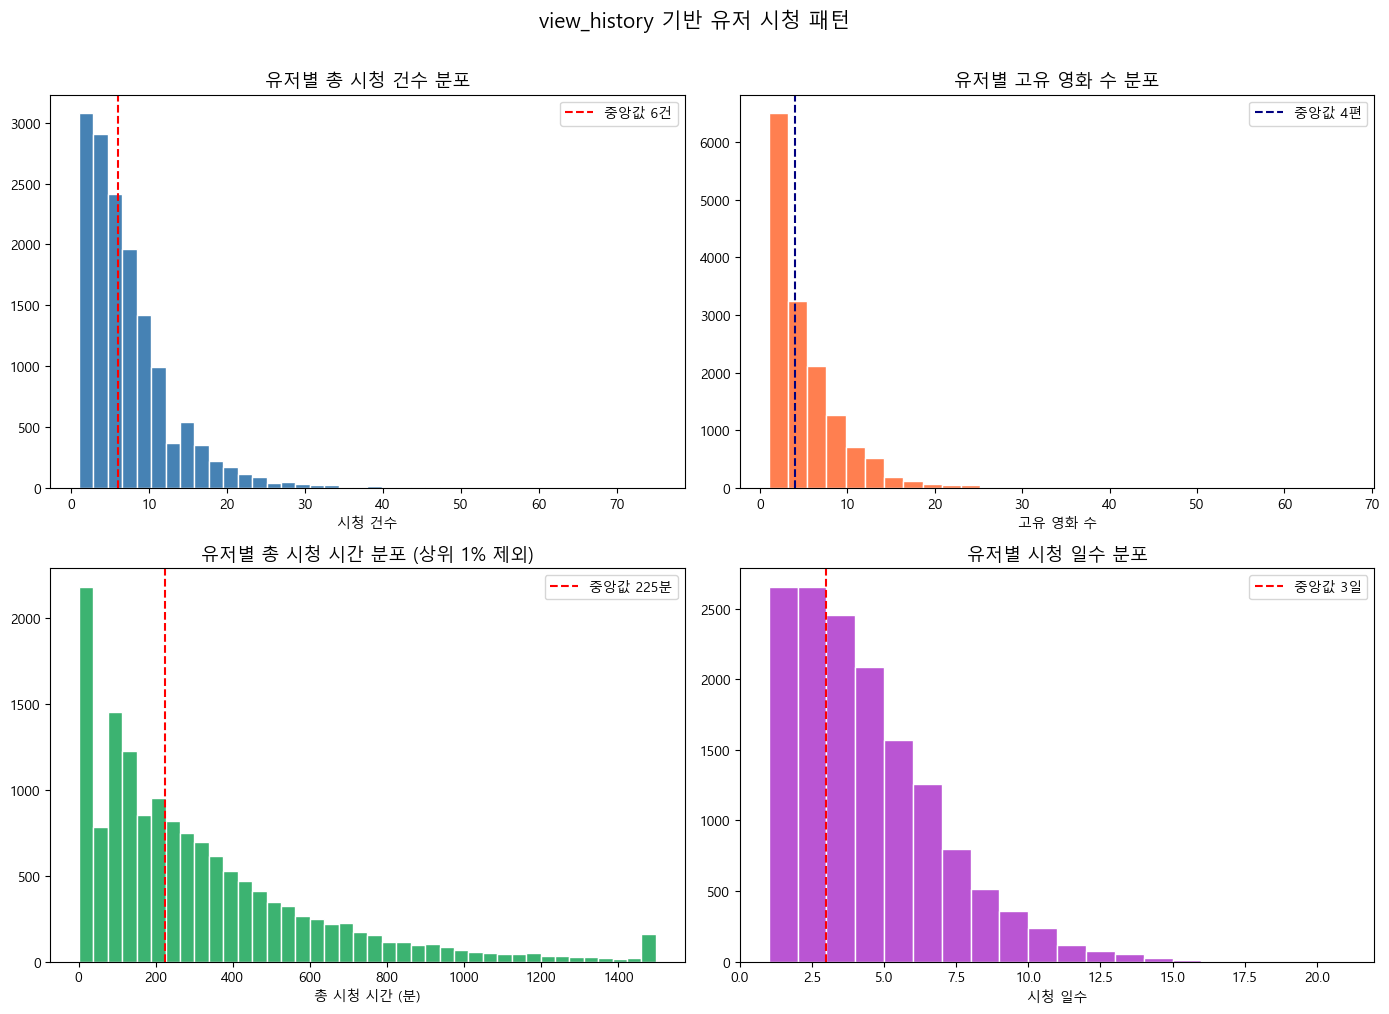

In [20]:
# 유저별 시청 통계
user_stat = view_history.groupby('USER_ID').agg(
    총시청건수=('MOVIE_ID', 'count'),
    고유영화수=('MOVIE_ID', 'nunique'),
    총시청시간=('DURATION', 'sum'),
    시청일수=('WATCH_DAY', 'nunique')
).reset_index()

print('유저별 시청 통계 기초 분석:')
print(user_stat[['총시청건수','고유영화수','총시청시간','시청일수']].describe().round(1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(user_stat['총시청건수'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].axvline(user_stat['총시청건수'].median(), color='red', linestyle='--', label=f"중앙값 {user_stat['총시청건수'].median():.0f}건")
axes[0,0].set_title('유저별 총 시청 건수 분포', fontsize=13)
axes[0,0].set_xlabel('시청 건수')
axes[0,0].legend()

axes[0,1].hist(user_stat['고유영화수'], bins=30, color='coral', edgecolor='white')
axes[0,1].axvline(user_stat['고유영화수'].median(), color='navy', linestyle='--', label=f"중앙값 {user_stat['고유영화수'].median():.0f}편")
axes[0,1].set_title('유저별 고유 영화 수 분포', fontsize=13)
axes[0,1].set_xlabel('고유 영화 수')
axes[0,1].legend()

axes[1,0].hist(user_stat['총시청시간'].clip(upper=user_stat['총시청시간'].quantile(0.99)), bins=40, color='mediumseagreen', edgecolor='white')
axes[1,0].axvline(user_stat['총시청시간'].median(), color='red', linestyle='--', label=f"중앙값 {user_stat['총시청시간'].median():.0f}분")
axes[1,0].set_title('유저별 총 시청 시간 분포 (상위 1% 제외)', fontsize=13)
axes[1,0].set_xlabel('총 시청 시간 (분)')
axes[1,0].legend()

axes[1,1].hist(user_stat['시청일수'], bins=20, color='mediumorchid', edgecolor='white')
axes[1,1].axvline(user_stat['시청일수'].median(), color='red', linestyle='--', label=f"중앙값 {user_stat['시청일수'].median():.0f}일")
axes[1,1].set_title('유저별 시청 일수 분포', fontsize=13)
axes[1,1].set_xlabel('시청 일수')
axes[1,1].legend()

plt.suptitle('view_history 기반 유저 시청 패턴', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

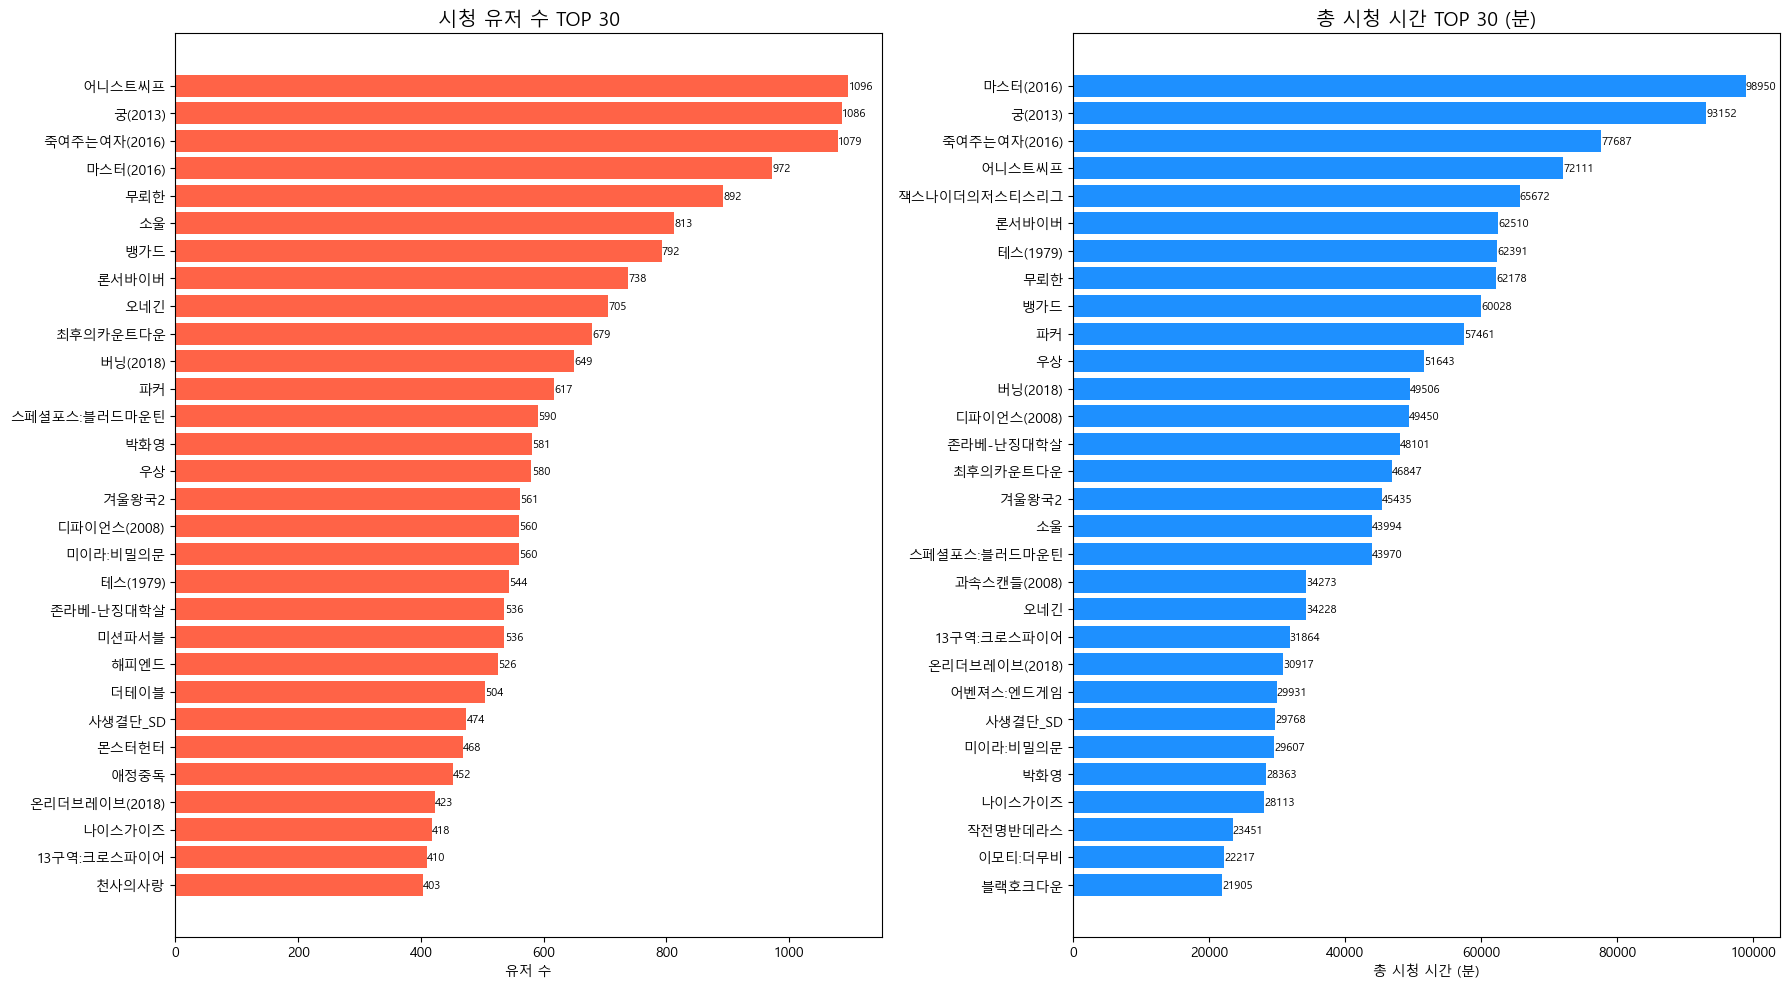


시청 유저 수 TOP 10:
       TITLE                        GENRE  시청유저수  시청횟수  총시청시간
      어니스트씨프             액션, 범죄, 드라마, 스릴러   1096  1675  72111
     궁(2013)                코미디, 드라마, 로맨스   1086  1345  93152
죽여주는여자(2016)                          드라마   1079  1354  77687
   마스터(2016)                 드라마, 유럽에서 제작    972  1374  98950
         무뢰한            드라마, 범죄, 로맨스, 스릴러    892  1104  62178
          소울 판타지, 애니메이션, 가족, 드라마, 음악, 코미디    813  1873  43994
         뱅가드             액션, 코미디, 범죄, 스릴러    792  1236  60028
       론서바이버                           액션    738   971  62510
         오네긴                     로맨스, 드라마    705   841  34228
    최후의카운트다운       드라마, 스릴러, 코미디, 액션, 로맨스    679   861  46847


In [21]:
# 영화별 시청 통계
movie_views = view_history.groupby('MOVIE_ID').agg(
    시청횟수=('USER_ID', 'count'),
    시청유저수=('USER_ID', 'nunique'),
    총시청시간=('DURATION', 'sum'),
    평균시청시간=('DURATION', 'mean')
).reset_index()

movie_views = movie_views.merge(mm[['MOVIE_ID','TITLE','GENRE','COUNTRY']], on='MOVIE_ID', how='left')
movie_views = movie_views.sort_values('시청유저수', ascending=False)

top30 = movie_views.head(30)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

axes[0].barh(top30['TITLE'][::-1], top30['시청유저수'][::-1], color='tomato')
axes[0].set_title('시청 유저 수 TOP 30', fontsize=14)
axes[0].set_xlabel('유저 수')
for i, v in enumerate(top30['시청유저수'][::-1]):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=8)

top30_dur = movie_views.sort_values('총시청시간', ascending=False).head(30)
axes[1].barh(top30_dur['TITLE'][::-1], top30_dur['총시청시간'][::-1], color='dodgerblue')
axes[1].set_title('총 시청 시간 TOP 30 (분)', fontsize=14)
axes[1].set_xlabel('총 시청 시간 (분)')
for i, v in enumerate(top30_dur['총시청시간'][::-1]):
    axes[1].text(v + 0.3, i, f'{v:.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\n시청 유저 수 TOP 10:')
print(top30[['TITLE','GENRE','시청유저수','시청횟수','총시청시간']].head(10).to_string(index=False))

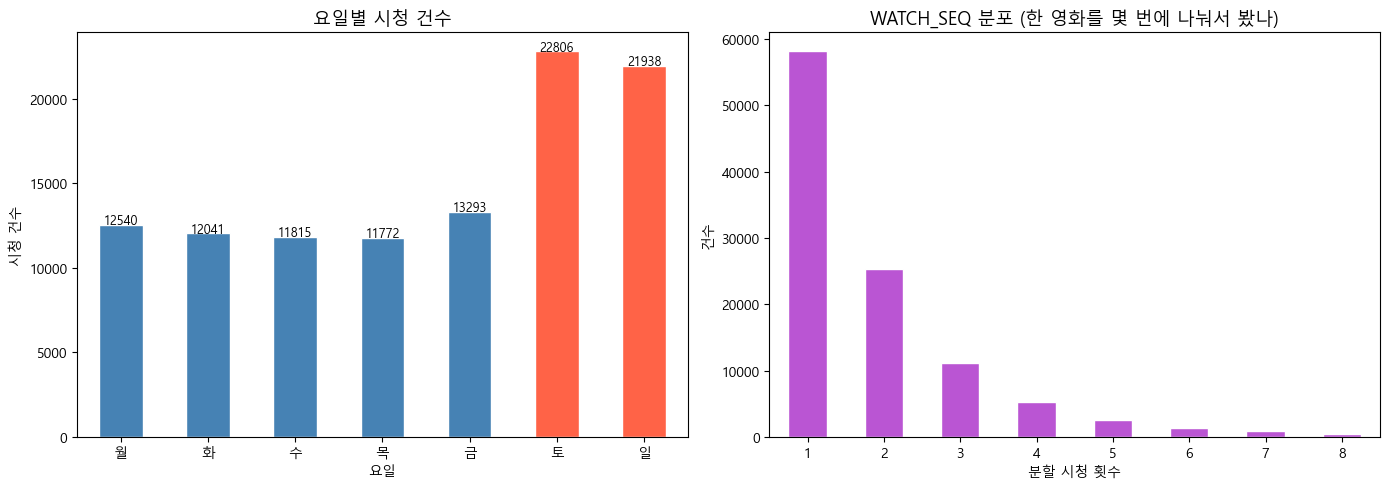

In [22]:
import datetime

# 요일별 시청 분포
def to_weekday(d):
    try:
        return datetime.datetime.strptime(str(int(d)), '%Y%m%d').weekday()
    except:
        return None

view_history['weekday'] = view_history['WATCH_DAY'].apply(to_weekday)
wd_labels = ['월','화','수','목','금','토','일']
wd_counts = view_history['weekday'].value_counts().sort_index()
wd_counts.index = [wd_labels[i] for i in wd_counts.index]

# WATCH_SEQ 분포
seq_dist = view_history['WATCH_SEQ'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wd_counts.plot(kind='bar', ax=axes[0], color=['steelblue']*5+['tomato']*2, edgecolor='white')
axes[0].set_title('요일별 시청 건수', fontsize=13)
axes[0].set_xlabel('요일')
axes[0].set_ylabel('시청 건수')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(wd_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)

seq_dist.head(8).plot(kind='bar', ax=axes[1], color='mediumorchid', edgecolor='white')
axes[1].set_title('WATCH_SEQ 분포 (한 영화를 몇 번에 나눠서 봤나)', fontsize=13)
axes[1].set_xlabel('분할 시청 횟수')
axes[1].set_ylabel('건수')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

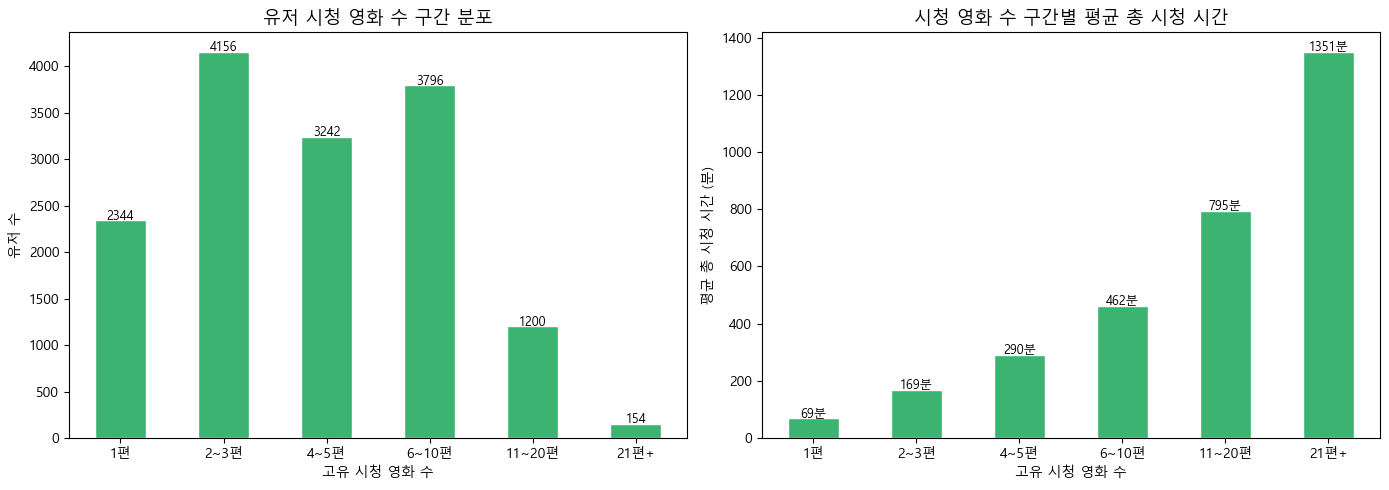


구간별 유저 수:
시청구간
1편        2344
2~3편      4156
4~5편      3242
6~10편     3796
11~20편    1200
21편+       154


In [23]:
# 헤비/라이트 유저 구간 분류
bins = [0, 1, 3, 5, 10, 20, 9999]
labels = ['1편', '2~3편', '4~5편', '6~10편', '11~20편', '21편+']
user_stat['시청구간'] = pd.cut(user_stat['고유영화수'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cnt = user_stat['시청구간'].value_counts().reindex(labels)
cnt.plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('유저 시청 영화 수 구간 분포', fontsize=13)
axes[0].set_xlabel('고유 시청 영화 수')
axes[0].set_ylabel('유저 수')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(cnt):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

grp = user_stat.groupby('시청구간', observed=False)['총시청시간'].mean()
grp.plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('시청 영화 수 구간별 평균 총 시청 시간', fontsize=13)
axes[1].set_xlabel('고유 시청 영화 수')
axes[1].set_ylabel('평균 총 시청 시간 (분)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(grp):
    axes[1].text(i, v + 2, f'{v:.0f}분', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n구간별 유저 수:')
print(cnt.to_string())

## 10. 영화 완주율 — 상영시간 대비 시청 시간
얼마나 끝까지 봤는지 (duration_min이 있는 영화만)

완주율 기초통계:
count    75674.000
mean         0.496
std          0.426
min          0.004
25%          0.035
50%          0.423
75%          0.981
max          1.000
Name: completion, dtype: float64
완주(90%이상): 27601건 (36.5%)
중도포기(50%미만): 39501건 (52.2%)


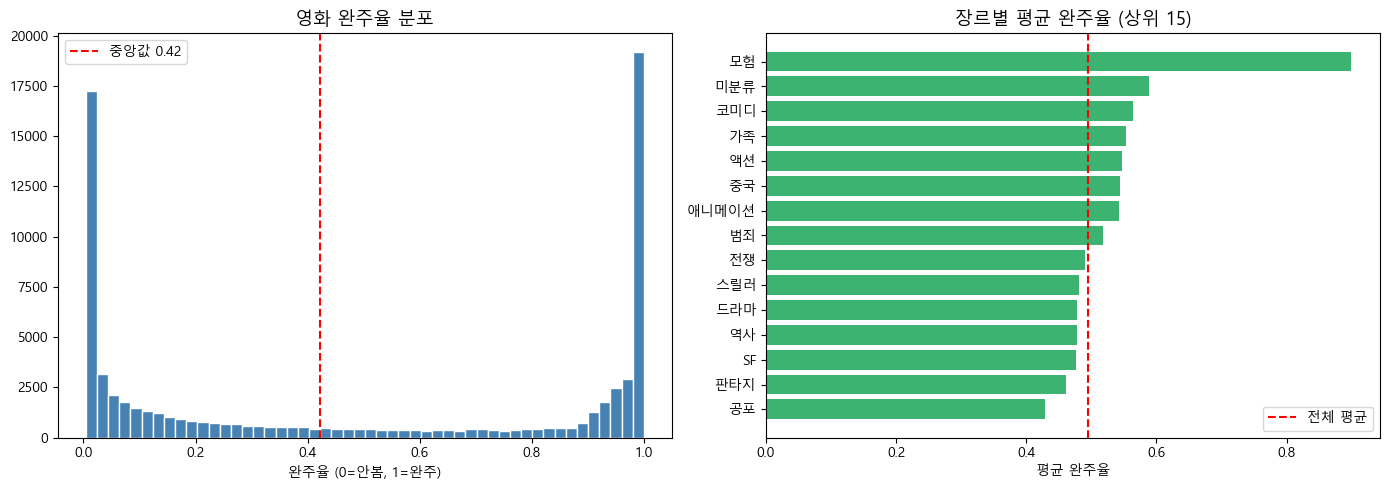

In [24]:
# WATCH_SEQ별로 합산 → 영화 1편당 총 시청시간 계산
vh_sum = view_history.groupby(['USER_ID', 'MOVIE_ID'])['DURATION'].sum().reset_index()
vh_sum.columns = ['USER_ID', 'MOVIE_ID', 'watched_min']

# 상영시간 조인
vh_sum = vh_sum.merge(mm[['MOVIE_ID', 'TITLE', 'GENRE', 'duration_min']], on='MOVIE_ID', how='left')
vh_sum = vh_sum[vh_sum['duration_min'].notna() & (vh_sum['duration_min'] > 0)]

# 완주율 = 시청시간 / 상영시간 (1 초과는 1로 클리핑)
vh_sum['completion'] = (vh_sum['watched_min'] / vh_sum['duration_min']).clip(upper=1.0)

print('완주율 기초통계:')
print(vh_sum['completion'].describe().round(3))
print(f"완주(90%이상): {(vh_sum['completion'] >= 0.9).sum()}건 ({(vh_sum['completion'] >= 0.9).mean()*100:.1f}%)")
print(f"중도포기(50%미만): {(vh_sum['completion'] < 0.5).sum()}건 ({(vh_sum['completion'] < 0.5).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(vh_sum['completion'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(vh_sum['completion'].median(), color='red', linestyle='--',
                label=f"중앙값 {vh_sum['completion'].median():.2f}")
axes[0].set_title('영화 완주율 분포', fontsize=13)
axes[0].set_xlabel('완주율 (0=안봄, 1=완주)')
axes[0].legend()

# 장르별 평균 완주율
vh_sum['main_genre'] = vh_sum['GENRE'].fillna('').apply(lambda x: x.split(',')[0].strip() if x else '미분류')
genre_completion = vh_sum.groupby('main_genre')['completion'].mean().sort_values(ascending=False)
top_genre_comp = genre_completion.head(15)
axes[1].barh(top_genre_comp.index[::-1], top_genre_comp.values[::-1], color='mediumseagreen')
axes[1].axvline(vh_sum['completion'].mean(), color='red', linestyle='--', label='전체 평균')
axes[1].set_title('장르별 평균 완주율 (상위 15)', fontsize=13)
axes[1].set_xlabel('평균 완주율')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. 시청 이력 유무 × repurchase
시청 기록이 있는 유저와 없는 유저의 재결제율 비교

has_history   유저수     재결제율
    시청기록 없음  2996 0.666889
    시청기록 있음 14849 0.661324


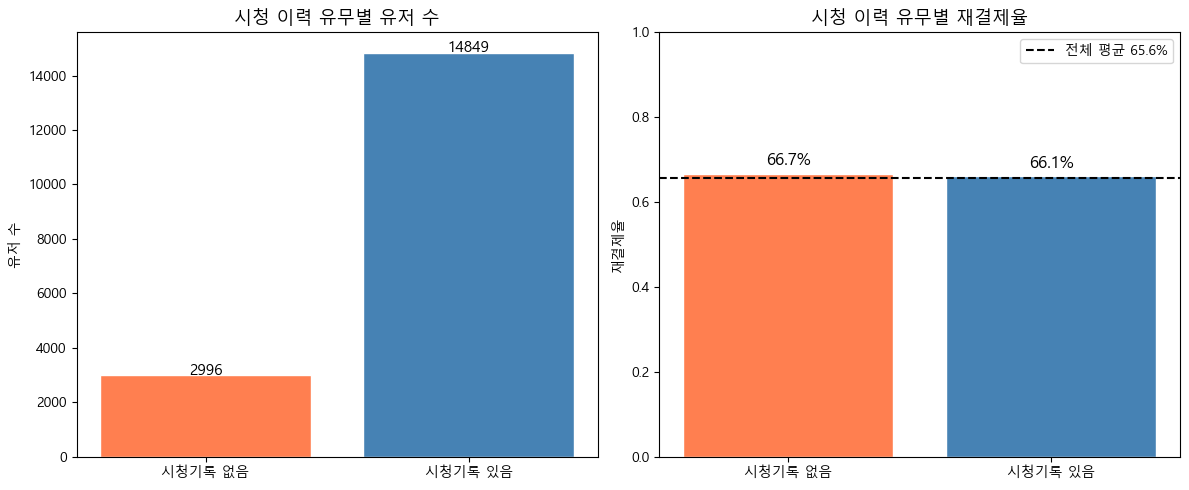

In [25]:
membership['repurchase_bin'] = membership['repurchase'].apply(lambda x: 1 if x == 'O' else 0)
uid_map2 = user_mapping.rename(columns={'uid': 'user_no'})

# membership에 USER_ID 붙이기
mem_uid = membership.merge(uid_map2[['user_no','USER_ID']], on='user_no', how='left')

# 시청 이력 유무
users_with_history = set(view_history['USER_ID'].unique())
mem_uid['has_history'] = mem_uid['USER_ID'].apply(lambda x: 1 if x in users_with_history else 0)

stat = mem_uid.groupby('has_history').agg(
    유저수=('user_no', 'count'),
    재결제율=('repurchase_bin', 'mean')
).reset_index()
stat['has_history'] = stat['has_history'].map({0: '시청기록 없음', 1: '시청기록 있음'})
print(stat.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(stat['has_history'], stat['유저수'], color=['coral','steelblue'], edgecolor='white')
axes[0].set_title('시청 이력 유무별 유저 수', fontsize=13)
axes[0].set_ylabel('유저 수')
for i, v in enumerate(stat['유저수']):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=11)

bars = axes[1].bar(stat['has_history'], stat['재결제율'], color=['coral','steelblue'], edgecolor='white')
axes[1].axhline(0.656, color='black', linestyle='--', label='전체 평균 65.6%')
axes[1].set_title('시청 이력 유무별 재결제율', fontsize=13)
axes[1].set_ylabel('재결제율')
axes[1].set_ylim(0, 1)
axes[1].legend()
for bar, v in zip(bars, stat['재결제율']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.1%}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## 12. 장르 다양성 × repurchase
다양한 장르를 본 유저가 덜 이탈하는지

장르다양성  유저수     재결제율
  1장르 2850 0.671589
  2장르 3138 0.666454
  3장르 3003 0.657411
4~5장르 4108 0.651123
 6장르+ 1793 0.665921


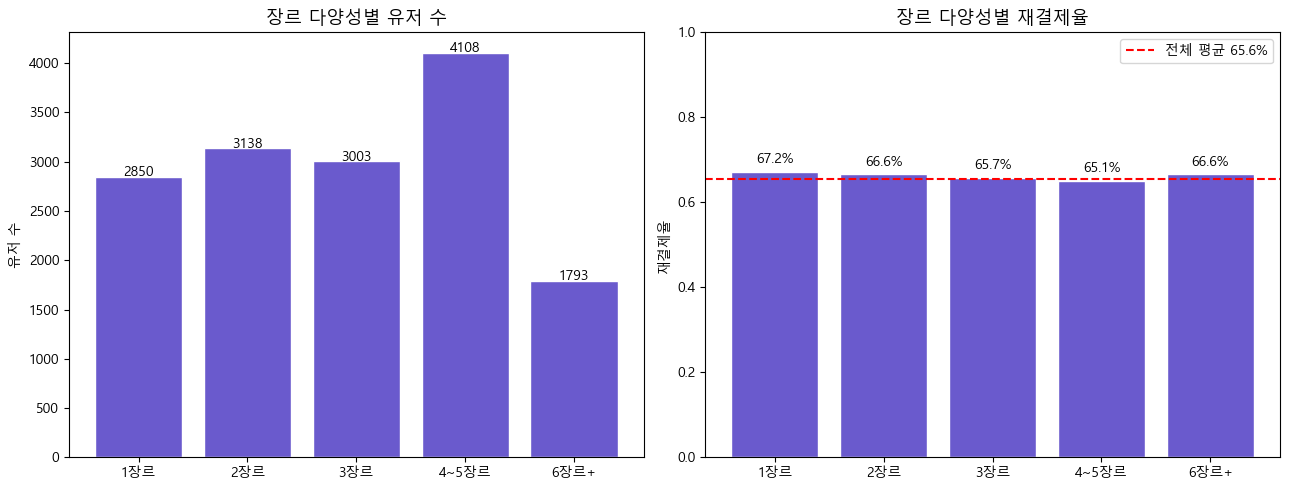

In [26]:
# 유저별 시청 장르 다양성
vh_genre2 = view_history.merge(mm[['MOVIE_ID','main_genre']], on='MOVIE_ID', how='left')
user_genre_div = vh_genre2.groupby('USER_ID').agg(
    고유장르수=('main_genre', 'nunique')
).reset_index()

# repurchase 붙이기
user_genre_div = user_genre_div.merge(uid_map2[['user_no','USER_ID']], on='USER_ID', how='left')
user_genre_div = user_genre_div.merge(membership[['user_no','repurchase_bin']], on='user_no', how='left')

bins_g = [0, 1, 2, 3, 5, 100]
labels_g = ['1장르', '2장르', '3장르', '4~5장르', '6장르+']
user_genre_div['장르다양성'] = pd.cut(user_genre_div['고유장르수'], bins=bins_g, labels=labels_g)

div_stat = user_genre_div.groupby('장르다양성', observed=False).agg(
    유저수=('USER_ID', 'count'),
    재결제율=('repurchase_bin', 'mean')
).reset_index()
print(div_stat.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(div_stat['장르다양성'], div_stat['유저수'], color='slateblue', edgecolor='white')
axes[0].set_title('장르 다양성별 유저 수', fontsize=13)
axes[0].set_ylabel('유저 수')
for i, v in enumerate(div_stat['유저수']):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=10)

bars = axes[1].bar(div_stat['장르다양성'], div_stat['재결제율'], color='slateblue', edgecolor='white')
axes[1].axhline(0.656, color='red', linestyle='--', label='전체 평균 65.6%')
axes[1].set_title('장르 다양성별 재결제율', fontsize=13)
axes[1].set_ylabel('재결제율')
axes[1].set_ylim(0, 1)
axes[1].legend()
for bar, v in zip(bars, div_stat['재결제율']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 13. 국내 vs 해외 영화 시청 × repurchase
한국 영화 위주로 보는 유저 vs 해외 영화 위주 유저의 재결제율

posx and posy should be finite values


     국내외구분  유저수     재결제율
    해외100% 6261 0.661546
해외위주(~30%) 3605 0.660267
혼합(30~70%) 3466 0.668983
국내위주(70%~) 1560 0.645847
    국내100%    0      NaN


posx and posy should be finite values


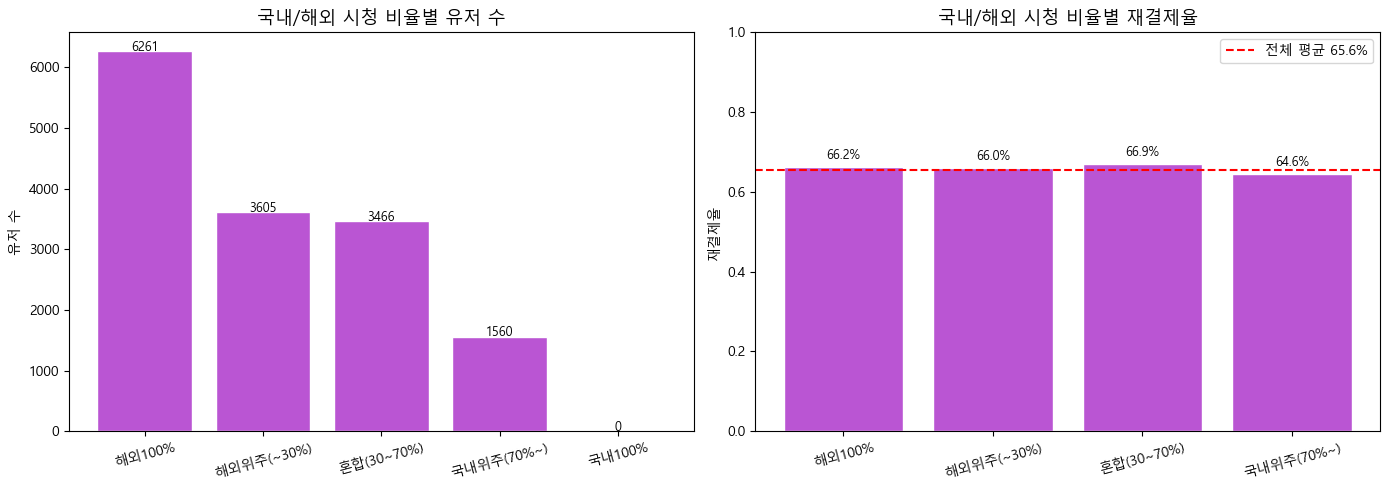

In [27]:
mm['is_korean'] = mm['COUNTRY'].fillna('').apply(lambda x: 1 if '대한민국' in x or '한국' in x else 0)

vh_country = view_history.merge(mm[['MOVIE_ID','is_korean']], on='MOVIE_ID', how='left')

# 유저별 한국 영화 비율
user_kr = vh_country.groupby('USER_ID').agg(
    총시청=('MOVIE_ID', 'count'),
    한국영화시청=('is_korean', 'sum')
).reset_index()
user_kr['한국비율'] = user_kr['한국영화시청'] / user_kr['총시청']

bins_k = [-0.01, 0.0, 0.3, 0.7, 1.0, 1.01]
labels_k = ['해외100%', '해외위주(~30%)', '혼합(30~70%)', '국내위주(70%~)', '국내100%']
user_kr['국내외구분'] = pd.cut(user_kr['한국비율'], bins=bins_k, labels=labels_k)

# repurchase 붙이기
user_kr = user_kr.merge(uid_map2[['user_no','USER_ID']], on='USER_ID', how='left')
user_kr = user_kr.merge(membership[['user_no','repurchase_bin']], on='user_no', how='left')

kr_stat = user_kr.groupby('국내외구분', observed=False).agg(
    유저수=('USER_ID', 'count'),
    재결제율=('repurchase_bin', 'mean')
).reset_index()
print(kr_stat.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(kr_stat['국내외구분'], kr_stat['유저수'], color='mediumorchid', edgecolor='white')
axes[0].set_title('국내/해외 시청 비율별 유저 수', fontsize=13)
axes[0].set_ylabel('유저 수')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(kr_stat['유저수']):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=9)

bars = axes[1].bar(kr_stat['국내외구분'], kr_stat['재결제율'], color='mediumorchid', edgecolor='white')
axes[1].axhline(0.656, color='red', linestyle='--', label='전체 평균 65.6%')
axes[1].set_title('국내/해외 시청 비율별 재결제율', fontsize=13)
axes[1].set_ylabel('재결제율')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()
for bar, v in zip(bars, kr_stat['재결제율']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 14. 몰아보기(Binge-watch) 패턴 × repurchase
하루에 여러 편을 본 유저가 더 충성도가 높은지

몰아보기구분  유저수     재결제율
  1편/일 5262 0.666603
  2편/일 4778 0.656597
  3편/일 2486 0.659806
4~5편/일 1701 0.682941
 6편+/일  665 0.603631


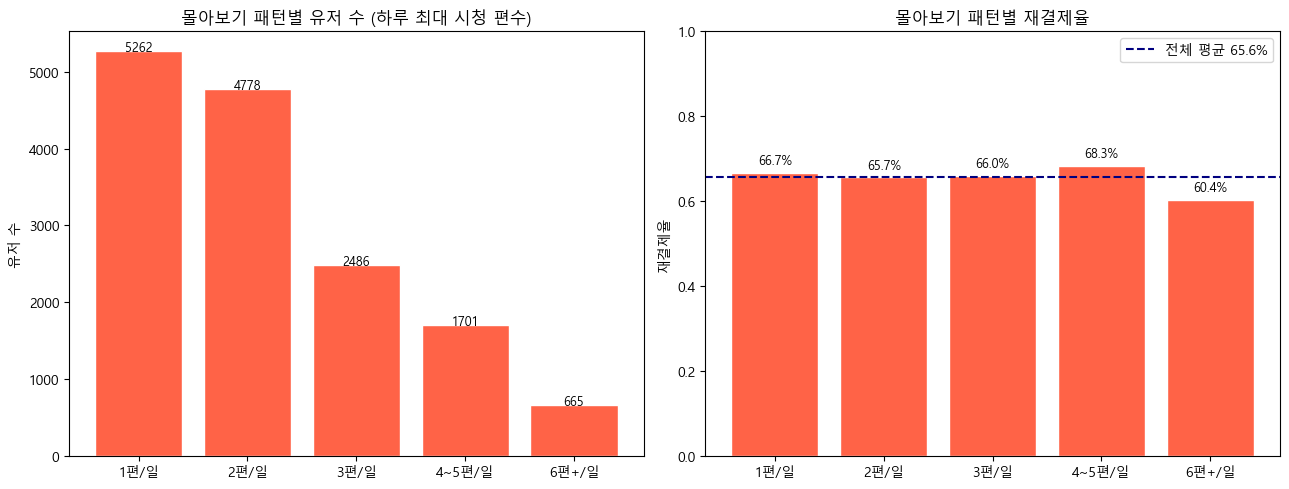

In [28]:
# 유저별 하루 최대 시청 편수
daily_watch = view_history.groupby(['USER_ID','WATCH_DAY'])['MOVIE_ID'].nunique().reset_index()
daily_watch.columns = ['USER_ID', 'WATCH_DAY', '하루시청편수']

user_binge = daily_watch.groupby('USER_ID').agg(
    하루최대편수=('하루시청편수', 'max'),
    하루평균편수=('하루시청편수', 'mean')
).reset_index()

bins_b = [0, 1, 2, 3, 5, 100]
labels_b = ['1편/일', '2편/일', '3편/일', '4~5편/일', '6편+/일']
user_binge['몰아보기구분'] = pd.cut(user_binge['하루최대편수'], bins=bins_b, labels=labels_b)

# repurchase 붙이기
user_binge = user_binge.merge(uid_map2[['user_no','USER_ID']], on='USER_ID', how='left')
user_binge = user_binge.merge(membership[['user_no','repurchase_bin']], on='user_no', how='left')

binge_stat = user_binge.groupby('몰아보기구분', observed=False).agg(
    유저수=('USER_ID', 'count'),
    재결제율=('repurchase_bin', 'mean')
).reset_index()
print(binge_stat.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(binge_stat['몰아보기구분'], binge_stat['유저수'], color='tomato', edgecolor='white')
axes[0].set_title('몰아보기 패턴별 유저 수 (하루 최대 시청 편수)', fontsize=12)
axes[0].set_ylabel('유저 수')
for i, v in enumerate(binge_stat['유저수']):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=9)

bars = axes[1].bar(binge_stat['몰아보기구분'], binge_stat['재결제율'], color='tomato', edgecolor='white')
axes[1].axhline(0.656, color='navy', linestyle='--', label='전체 평균 65.6%')
axes[1].set_title('몰아보기 패턴별 재결제율', fontsize=12)
axes[1].set_ylabel('재결제율')
axes[1].set_ylim(0, 1)
axes[1].legend()
for bar, v in zip(bars, binge_stat['재결제율']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()